# Calculating the continuous flux $\phi(E_{\nu}, \vec{\xi}_{flux})$

## Part 1: Adapting Daya-Bay flux measurements to the specific composition of JUNO

In [1]:
from src.readDayaBay import read_total_flux, read_covariance_matrix, recast_covariance_matrix

DYB_PATH = "data/DYB_unfolded_spectra_tot_U235_Pu239.txt"

df_total = read_total_flux(DYB_PATH, "Total")
C_ij = read_covariance_matrix(DYB_PATH)
Psi_ik = recast_covariance_matrix(C_ij)

Phi0 = df_total["Flux"]
E_high = df_total["E_high"]
E_low = df_total["E_low"]
E_center = df_total["E_center"].to_numpy()
nbin = len(E_center)

Plotting raw $\Phi^0_i$ with $i = 1 \dots 25$ against the center prompt energy for bin i

Text(0, 0.5, '$\\Phi^0_i (10^{-43}$/MeV/fission)')

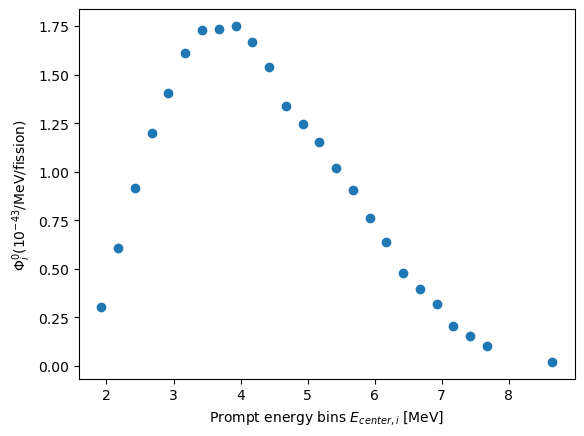

In [2]:
import matplotlib.pyplot as plt

plt.plot(E_center, Phi0, 'o')
plt.xlabel(r"Prompt energy bins $E_{center,i}$ [MeV]")
plt.ylabel(r"$\Phi^0_i (10^{-43}$/MeV/fission)")

## Part 2: Recasting the covariance matrix to the pull formalism
Plotting different pulls for the flux ($\Phi_i(\vec{\xi_{flux}}) = \Phi^0_i + \Sigma_k \Psi_{ik}\xi^k_{flux}$)

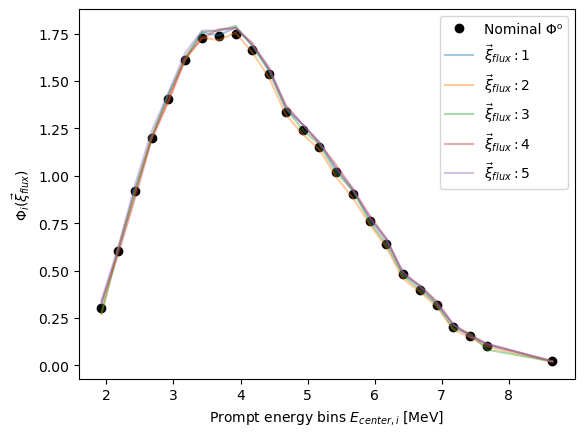

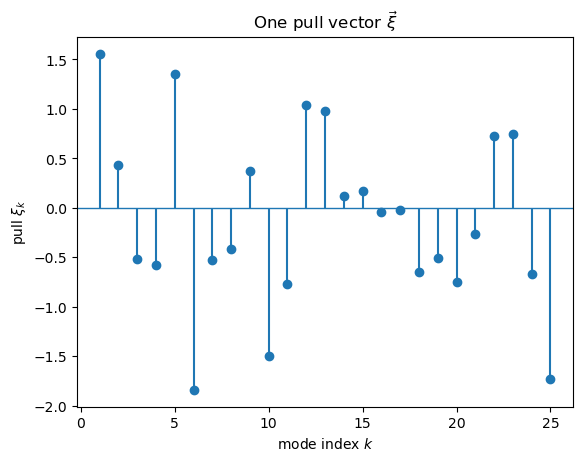

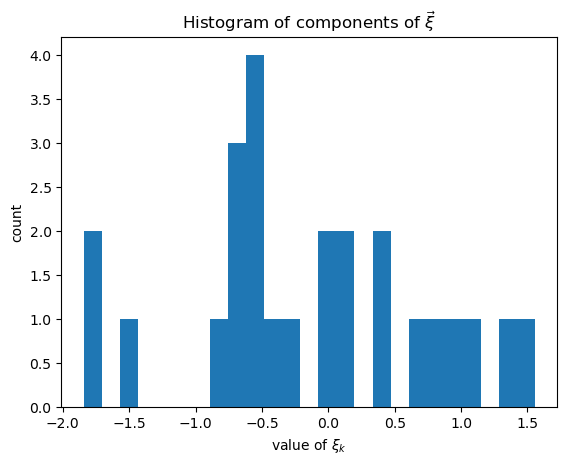

In [3]:
import numpy as np

xi = np.random.normal(0, 1, size=nbin)

Phi_tilde = Phi0 + Psi_ik @ xi

plt.plot(E_center, Phi0, 'o', color="black", label="Nominal Φ⁰")

for t in range(5):  
    xi = np.random.normal(0, 1, size=nbin)
    Phi_toy = Phi0 + Psi_ik @ xi
    plt.plot(E_center, Phi_toy, alpha=0.4, label=r"$\vec{\xi}_{flux}:$" f"{t+1}")

plt.xlabel(r"Prompt energy bins $E_{center,i}$ [MeV]")
plt.ylabel(r"$\Phi_i(\vec{\xi}_{flux})$")
plt.legend()

k = np.arange(1, nbin+1)
plt.figure()
plt.stem(k, xi, basefmt=" ")
plt.axhline(0, lw=1)
plt.xlabel(r"mode index $k$")
plt.ylabel(r"pull $\xi_k$")
plt.title(r"One pull vector $\vec{\xi}$")
plt.show()

plt.figure()
plt.hist(xi, bins=nbin)
plt.xlabel(r"value of $\xi_k$")
plt.ylabel("count")
plt.title(r"Histogram of components of $\vec{\xi}$")
plt.show()

## Part 3: Converting the bin-averaged IBD-weighted spectra into a continuous flux 

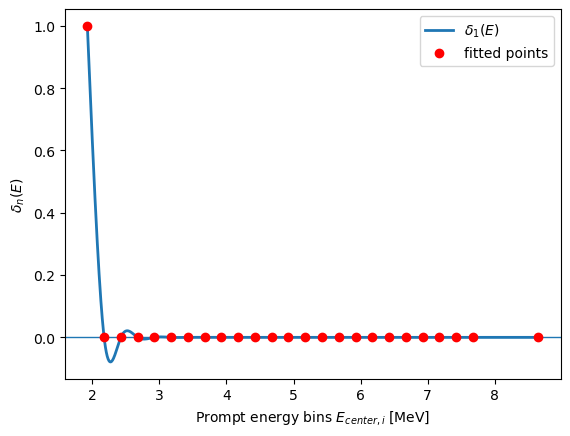


=== Piecewise cubics for δ_1(E) around the peak at E = 1.925000 MeV ===

-- Right of the peak (interval starting at E_n) --

Interval [1.925000, 2.175000] MeV
a = 1.714874831559e+01
b = 3.552713678801e-15
c = -5.071796769724e+00
d = 1.000000000000e+00

Explicit expression (numeric):
S(E) = 1.714874831559e+01*(E - 1.925000)^3 + 3.552713678801e-15*(E - 1.925000)^2 + -5.071796769724e+00*(E - 1.925000) + 1.000000000000e+00


In [4]:
from src.deltaSplines import create_delta_basis

delta, splines, I = create_delta_basis(E_center)
Egrid = np.linspace(E_center[0], E_center[-1], 1000)

n = 0
plt.figure()
plt.plot(Egrid, delta(n, Egrid), lw=2, label=rf"$\delta_{{{n+1}}}(E)$")
plt.scatter(E_center, I[n], color="red", zorder=3, label="fitted points")
plt.axhline(0, lw=1)
plt.xlabel(r"Prompt energy bins $E_{center,i}$ [MeV]")
plt.ylabel(r"$\delta_n(E)$")
plt.legend()
plt.show()

sp = splines[n]  

def print_piece(j):
    a, b, c, d = sp.c[:, j]
    xj = sp.x[j]
    xj1 = sp.x[j+1]

    print(f"\nInterval [{xj:.6f}, {xj1:.6f}] MeV")
    print(f"a = {a:.12e}")
    print(f"b = {b:.12e}")
    print(f"c = {c:.12e}")
    print(f"d = {d:.12e}")

    print("\nExplicit expression (numeric):")
    print(f"S(E) = {a:.12e}*(E - {xj:.6f})^3 "
          f"+ {b:.12e}*(E - {xj:.6f})^2 "
          f"+ {c:.12e}*(E - {xj:.6f}) "
          f"+ {d:.12e}")

print(f"\n=== Piecewise cubics for δ_{n+1}(E) around the peak at E = {E_center[n]:.6f} MeV ===")

if n >= 1:
    print("\n-- Left of the peak (interval ending at E_n) --")
    print_piece(n-1)

if n <= len(E_center) - 2:
    print("\n-- Right of the peak (interval starting at E_n) --")
    print_piece(n)




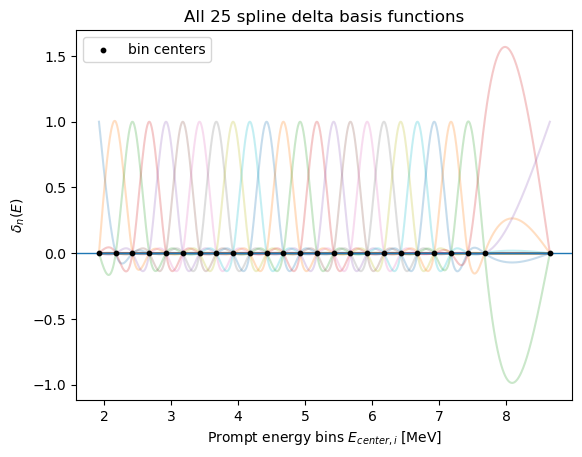


=== FULL piecewise definition for δ_25(E) ===

For E in [1.925000, 2.175000]:
S(E) = 1.714875e+01(E-1.925000)^3 + 3.552714e-15(E-1.925000)^2 + -5.071797e+00(E-1.925000) + 1.000000e+00

For E in [2.175000, 2.425000]:
S(E) = -2.174374e+01(E-2.175000)^3 + 1.286156e+01(E-2.175000)^2 + -1.856406e+00(E-2.175000) + 0.000000e+00

For E in [2.425000, 2.675000]:
S(E) = 5.826218e+00(E-2.425000)^3 + -3.446245e+00(E-2.425000)^2 + 4.974226e-01(E-2.425000) + 0.000000e+00

For E in [2.675000, 2.925000]:
S(E) = -1.561130e+00(E-2.675000)^3 + 9.234186e-01(E-2.675000)^2 + -1.332840e-01(E-2.675000) + 0.000000e+00

For E in [2.925000, 3.175000]:
S(E) = 4.183036e-01(E-2.925000)^3 + -2.474293e-01(E-2.925000)^2 + 3.571334e-02(E-2.925000) + 0.000000e+00

For E in [3.175000, 3.425000]:
S(E) = -1.120841e-01(E-3.175000)^3 + 6.629847e-02(E-3.175000)^2 + -9.569360e-03(E-3.175000) + 0.000000e+00

For E in [3.425000, 3.675000]:
S(E) = 3.003285e-02(E-3.425000)^3 + -1.776462e-02(E-3.425000)^2 + 2.564102e-03(E-3.425000)

In [5]:
for n in range(len(E_center)):
    plt.plot(Egrid, delta(n, Egrid), alpha=0.25)   


plt.scatter(E_center, np.zeros_like(E_center),
            color="black", s=10, zorder=3, label="bin centers")

plt.axhline(0, lw=1)
plt.xlabel(r"Prompt energy bins $E_{center,i}$ [MeV]")
plt.ylabel(r"$\delta_n(E)$")
plt.title("All 25 spline delta basis functions")
plt.legend()
plt.show()

print(f"\n=== FULL piecewise definition for δ_{n+1}(E) ===")
for j in range(len(E_center) - 1):
    a, b, c, d = sp.c[:, j]
    xj, xj1 = sp.x[j], sp.x[j+1]
    print(f"\nFor E in [{xj:.6f}, {xj1:.6f}]:")
    print(f"S(E) = {a:.6e}(E-{xj:.6f})^3 + {b:.6e}(E-{xj:.6f})^2 + {c:.6e}(E-{xj:.6f}) + {d:.6e}")

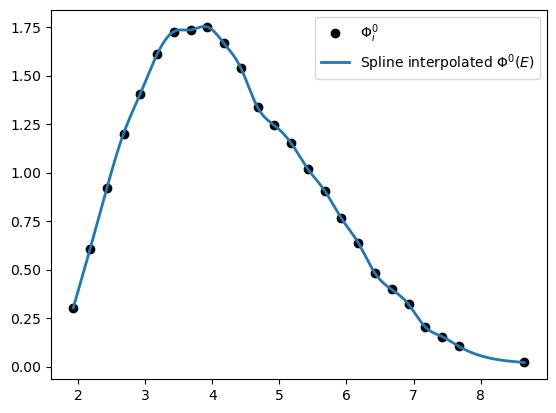

In [6]:
from scipy.interpolate import CubicSpline

Phi_spline = CubicSpline(E_center, Phi0, bc_type="natural")
plt.figure()
plt.plot(E_center, Phi0, "o", color="black", label=r"$\Phi_i^0$")
plt.plot(Egrid, Phi_spline(Egrid), lw=2, label=r"Spline interpolated $\Phi^0(E)$")
plt.legend()
plt.show()

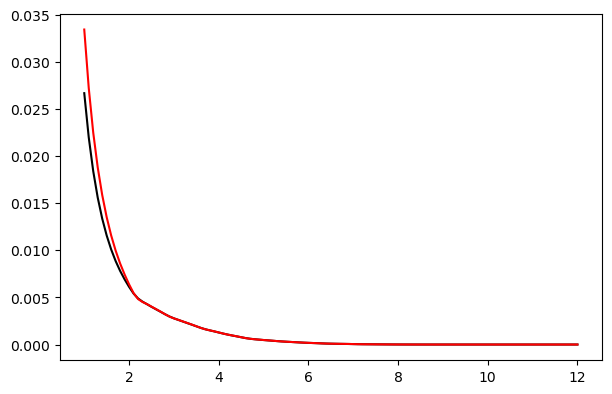

In [7]:
import pandas as pd

dfC = pd.read_csv("data/flux-C.dat.xz", sep=r"\s+", header=None, compression="xz")
dfM = pd.read_csv("data/flux-M.dat.xz", sep=r"\s+", header=None, compression="xz")

plt.figure(figsize=(7,4.5))

plt.plot(dfC[0], dfC[1], "k-", label="flux-C")
plt.plot(dfM[0], dfM[1], "r-", label="flux-M")

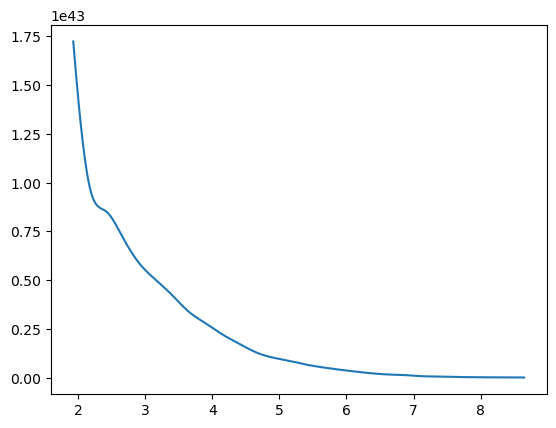

In [8]:
from src.phiHuber import phi_huber_weighted
from src.crossSectionIBD import sigma_ibd
import numpy as np

kg_to_MeV = 5.61e29
m_p = 1.6726219e-27 * kg_to_MeV
m_n = 1.6749275e-27 * kg_to_MeV
m_e = 9.1093837e-31 * kg_to_MeV
Delta = m_n - m_p

alpha = {
    "U235":  np.array([4.367, -4.577, 2.100, -5.294e-1, 6.186e-2, -2.777e-3]),
    "Pu239": np.array([4.757, -5.392, 2.563, -6.596e-1, 7.820e-2, -3.536e-3]),
    "Pu241": np.array([2.990, -2.882, 1.278, -3.343e-1, 3.905e-2, -1.754e-3]),
}

frac = {"U235": 0.564, "U238": 0.076, "Pu239": 0.304, "Pu241": 0.056}

nbin = len(E_center)

M_in = np.zeros((nbin, nbin), dtype=float)

for i in range(nbin):
    a, b = E_low[i], E_high[i]
    xs = np.linspace(a, b, 500)
    w  = phi_huber_weighted(xs, frac, alpha) * sigma_ibd(xs, Delta, m_e)

    for n in range(nbin):
        vals = w * delta(n, xs)
        M_in[i, n] = np.trapz(vals, xs) / (b - a)

y0 = np.linalg.solve(M_in, Phi0)          
Y  = np.linalg.solve(M_in, Psi_ik)      

def phi0_cont(E):
    E = np.asarray(E, dtype=float)
    # IMPORTANT: initialize accumulator
    s = np.zeros_like(E, dtype=float)

    for n in range(nbin):
        s += y0[n] * delta(n, E)
        
    return phi_huber_weighted(E, frac, alpha) * s

def psi_k_cont(E, k):
    E = np.asarray(E, dtype=float)

    # IMPORTANT: initialize accumulator
    s = np.zeros_like(E, dtype=float)

    for n in range(nbin):
        s += Y[n, k] * delta(n, E)

    return phi_huber_weighted(E, frac, alpha) * s

def phi(E, xi):
    if xi.shape != (nbin,):
        raise ValueError(f"xi must have shape ({nbin},).")

    out = phi0_cont(E).copy()
    for k in range(nbin):
        out += psi_k_cont(E, k) * xi[k]
    return out

Egrid = np.linspace(E_center[0], E_center[-1], 1000)
xi = np.random.normal(0, 1, size=nbin)
phi_vals  = phi(Egrid, xi)

plt.plot(Egrid, phi_vals)

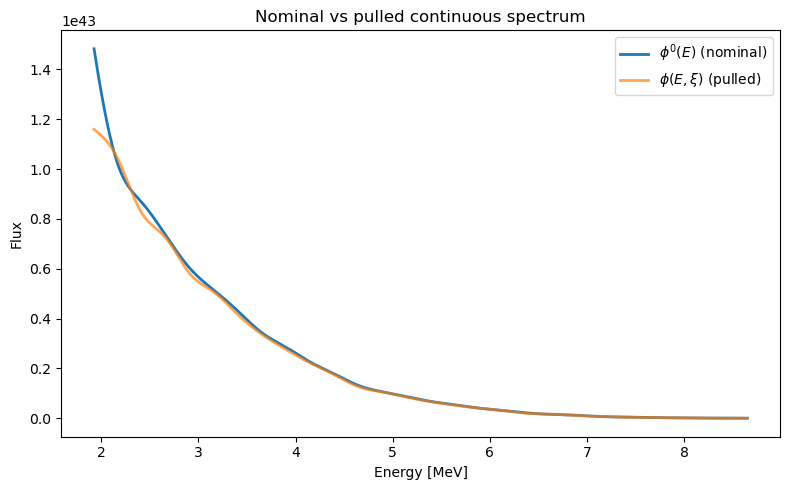

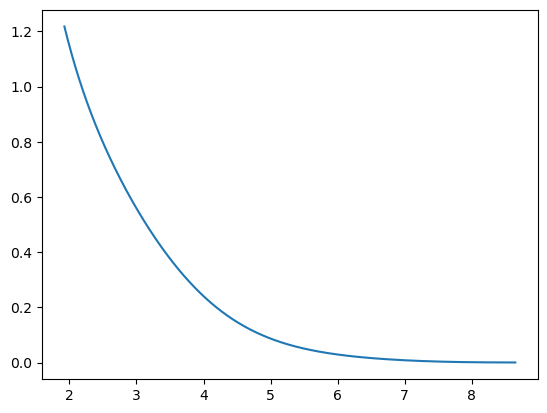

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from src.continuous_flux import build_continuous_flux_model
from src.phiHuber import phi_huber_weighted
from src.crossSectionIBD import sigma_ibd

kg_to_MeV = 5.61e29
m_p = 1.6726219e-27 * kg_to_MeV
m_n = 1.6749275e-27 * kg_to_MeV
m_e = 9.1093837e-31 * kg_to_MeV
Delta = m_n - m_p

alpha = {
    "U235":  np.array([4.367, -4.577, 2.100, -5.294e-1, 6.186e-2, -2.777e-3]),
    "Pu239": np.array([4.757, -5.392, 2.563, -6.596e-1, 7.820e-2, -3.536e-3]),
    "Pu241": np.array([2.990, -2.882, 1.278, -3.343e-1, 3.905e-2, -1.754e-3]),
}

frac = {"U235": 0.564, "U238": 0.076, "Pu239": 0.304, "Pu241": 0.056}

M_in = np.zeros((nbin, nbin), dtype=float)

N_int = 500
for i in range(nbin):
    a, b = E_low[i], E_high[i]
    xs = np.linspace(a, b, N_int)
    w  = phi_huber_weighted(xs, frac, alpha) * sigma_ibd(xs, Delta, m_e)

    for n in range(nbin):
        vals = w * delta(n, xs)
        M_in[i, n] = np.trapz(vals, xs) / (b - a)

y0 = np.linalg.solve(M_in, Phi0)          
Y  = np.linalg.solve(M_in, Psi_ik)

phi, extras = build_continuous_flux_model(
    E_center=E_center, E_low=E_low, E_high=E_high,
    Phi0=Phi0, Psi_ik=Psi_ik,
    delta=delta,
    phi_huber_weighted=phi_huber_weighted,
    sigma_ibd=sigma_ibd,
    frac=frac, alpha=alpha, Delta=Delta, m_e=m_e,
    N_int=500
)

Egrid = np.linspace(E_center[0], E_center[-1], 1000)
xi = np.random.normal(0, 1, size=extras["nbin"])

phi0_vals = extras["phi0_cont"](Egrid)
phi_vals  = phi(Egrid, xi)

plt.figure(figsize=(8, 5))
plt.plot(Egrid, phi0_vals, lw=2, label=r"$\phi^0(E)$ (nominal)")
plt.plot(Egrid, phi_vals,  lw=2, alpha=0.7, label=r"$\phi(E,\xi)$ (pulled)")
plt.xlabel("Energy [MeV]")
plt.ylabel("Flux")
plt.title("Nominal vs pulled continuous spectrum")
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(Egrid, phi_huber_weighted(Egrid, frac, alpha))


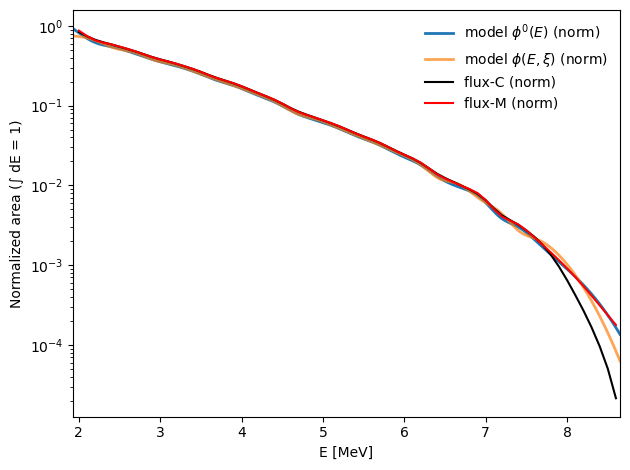

In [10]:
import numpy as np
import matplotlib.pyplot as plt

EC = dfC.iloc[:, 0].to_numpy()
FC = dfC.iloc[:, 1].to_numpy()
EM = dfM.iloc[:, 0].to_numpy()
FM = dfM.iloc[:, 1].to_numpy()

def normalize_area(x, y):
    area = np.trapz(y, x)
    return y / area if area != 0 else y

# normalize model curves on Egrid
phi0_norm = normalize_area(Egrid, phi0_vals)
phi_norm  = normalize_area(Egrid, phi_vals)

# restrict file curves to Egrid window, THEN normalize on that window
maskC = (EC >= Egrid[0]) & (EC <= Egrid[-1])
maskM = (EM >= Egrid[0]) & (EM <= Egrid[-1])

ECw = EC[maskC]
EMw = EM[maskM]

FC_norm = normalize_area(ECw, FC[maskC])
FM_norm = normalize_area(EMw, FM[maskM])

plt.figure()

plt.plot(Egrid, phi0_norm, lw=2, label=r"model $\phi^0(E)$ (norm)")
plt.plot(Egrid, phi_norm,  lw=2, alpha=0.7, label=r"model $\phi(E,\xi)$ (norm)")

plt.plot(ECw, FC_norm, "k-", lw=1.5, label="flux-C (norm)")
plt.plot(EMw, FM_norm, "r-", lw=1.5, label="flux-M (norm)")

plt.xlim(Egrid[0], Egrid[-1])
plt.xlabel("E [MeV]")
plt.ylabel("Normalized area (∫ dE = 1)")
plt.yscale("log")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
